In [1]:
import random

from typing import cast

import torch

from torch import nn
from torch import optim
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter

from torchvision.models import resnet18, ResNet18_Weights

import matplotlib.pyplot as plt

from utils.dataset import BaseImageFolderDataset, DomainDataset
from utils.sampler import DomainBatchSampler
from utils.criterion import MMD
from utils.transforms import base_transforms, train_source_transforms, train_target_transforms
from utils.metrics import bundle, metrics_with_mask, accuracy, mmd
from utils.trainer import train
from utils.typing import TrainHookF

In [2]:
GPU = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
SEED = 42

TRAIN_FRACTION = 0.01
LEARNING_RATE = 1e-4
BATCH_SIZE = 128

In [3]:
random.seed(SEED)

# PyTorch CPU
torch.manual_seed(SEED)

# PyTorch CUDA
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# PyTorch backend determinism
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
def plot_training_metrics(metrics_dict):
    """
    Plot training and validation metrics from a dictionary.

    Args:
        metrics_dict: Dictionary containing lists of metrics for each epoch
                      Expected keys: 'train_loss', 'train_acc1', 'train_acc5',
                                   'val_loss', 'val_acc1', 'val_acc5'
    """
    epochs = range(1, len(metrics_dict['train_loss']) + 1)

    # Create figure with subplots
    _, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

    # Plot 1: Loss curves
    ax1.plot(epochs, metrics_dict['train_loss'],
             'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, metrics_dict['val_loss'],
             'r-', label='Validation Loss', linewidth=2)
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Accuracy curves (Top-1 and Top-5)
    ax2.plot(epochs, metrics_dict['train_acc1'],
             'b-', label='Train Top-1', linewidth=2)
    ax2.plot(epochs, metrics_dict['val_acc1'],
             'r-', label='Val Top-1', linewidth=2)
    ax2.plot(epochs, metrics_dict['train_acc5'], 'b--',
             label='Train Top-5', linewidth=2, alpha=0.7)
    ax2.plot(epochs, metrics_dict['val_acc5'], 'r--',
             label='Val Top-5', linewidth=2, alpha=0.7)
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Training and Validation Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: MMD curve
    ax3.plot(epochs, metrics_dict['train_mmd'], 'b-', label='Train Top-1', linewidth=2)
    ax3.set_ylabel('MMD Loss')
    ax3.set_title('Training MMD')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [5]:
class VisDA2017Source(BaseImageFolderDataset):
    URL = 'http://csr.bu.edu/ftp/visda17/clf/train.tar'
    ARCHIVE_NAME = 'train.tar'
    EXTRACTED_FOLDER = 'train'


class VisDA2017Target(BaseImageFolderDataset):
    URL = 'http://csr.bu.edu/ftp/visda17/clf/test.tar'
    ARCHIVE_NAME = 'test.tar'
    EXTRACTED_FOLDER = 'test'


class VisDA2017Validation(BaseImageFolderDataset):
    URL = ' http://csr.bu.edu/ftp/visda17/clf/validation.tar'
    ARCHIVE_NAME = 'validation.tar'
    EXTRACTED_FOLDER = 'validation'

In [6]:
source_dataset = VisDA2017Source(
    './data', transform=train_source_transforms, download=True
)

target_dataset = VisDA2017Target(
    './data', transform=train_target_transforms, download=True
)

val_dataset = VisDA2017Validation(
    './data', transform=base_transforms, download=True
)

In [7]:
len(source_dataset), len(target_dataset), len(val_dataset)

(152397, 72372, 55388)

In [8]:
# TODO: Delete after tesing utils

import numpy as np
from torch.utils.data import Subset

np.random.seed(42)

# Generate random indices for split
source_indices = np.arange(len(source_dataset))
target_indices = np.arange(len(target_dataset))
val_indices = np.arange(len(val_dataset))

np.random.shuffle(source_indices)
np.random.shuffle(target_indices)
np.random.shuffle(val_indices)

source_size = int(len(source_dataset) * TRAIN_FRACTION)
target_size = int(len(target_dataset) * TRAIN_FRACTION)
val_size = int(len(val_dataset) * TRAIN_FRACTION)

source_indices = list(source_indices[:source_size])
target_indices = list(target_indices[:target_size])
val_indices = list(val_indices[:val_size])

source_dataset = Subset(source_dataset, source_indices)
target_dataset = Subset(target_dataset, target_indices)
val_dataset = Subset(val_dataset, val_indices)

In [9]:
train_dataset = DomainDataset(source_dataset, target_dataset)

train_sampler = DomainBatchSampler(
    source_size=len(source_dataset),
    target_size=len(target_dataset),
    batch_size=BATCH_SIZE,
)

In [10]:
train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_sampler=train_sampler,
    num_workers=4,
    pin_memory=True,
    prefetch_factor=4
)

val_dataloader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    prefetch_factor=4
)

In [11]:
class Criterion(nn.Module):
    def __init__(self, model, lambda_mmd: float = 0.5):
        super().__init__()
        self.model = model
        self.lambda_mmd = lambda_mmd

        self.ce = nn.CrossEntropyLoss()
        self.mmd = MMD()

    def forward(self, pred: torch.Tensor, y: torch.Tensor):
        mask = y != -1

        cls_loss = self.ce(pred[mask], y[mask])

        mmd = torch.tensor(0, device=y.device)

        if (~mask).sum() > 0:
            feat_l1 = self.model._feat_l1
            feat_l3 = self.model._feat_l3
            feat_fl = self.model._features

            mmd_1 = self.mmd(feat_l1[mask], feat_l1[~mask])
            mmd_2 = self.mmd(feat_l3[mask], feat_l3[~mask])
            mmd_3 = self.mmd(feat_fl[mask], feat_fl[~mask])

            # mmd_s = torch.stack([mmd_1, mmd_2, mmd_3])
            # weights = torch.softmax(mmd_s.detach(), dim=0)
            # mmd = (weights * mmd_s).sum()

            mmd = (mmd_1 + mmd_2 + mmd_3) / 3.0

        return cls_loss + self.lambda_mmd * mmd

In [12]:
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(512, 12)

model.layer1.register_forward_hook(
    lambda m, i, o: setattr(model, '_feat_l1', o.mean([2, 3]))
)
model.layer3.register_forward_hook(
    lambda m, i, o: setattr(model, '_feat_l3', o.mean([2, 3]))
)
model.avgpool.register_forward_hook(
    lambda m, i, o: setattr(model, '_features', torch.flatten(o, 1))
)

In [13]:
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
loss = Criterion(model, lambda_mmd=0.5)
metric_funcs = [metrics_with_mask(accuracy), mmd]

In [14]:
def build_hook(start_lambda: float, end_lambda: float, end_epoch: int) -> TrainHookF:
    def hook(
        epoch: int,
        model: nn.Module,
        optim: optim.Optimizer,
        criterion: nn.Module
    ) -> None:
        t = min(epoch / end_epoch, 1.0)
        new_lambda = start_lambda + t * (end_lambda - start_lambda)

        cast(Criterion, criterion).lambda_mmd = new_lambda
        print(f'New lambda: {new_lambda}')

    return hook

In [15]:
metrics = train(
    model,
    train_dataloader,
    val_dataloader,
    optimizer,
    loss,
    bundle(metric_funcs),
    epochs=60,
    start_epoch=0,
    checkpoint_interval=100,
    checkpoint_path='.',
    summary_writer=SummaryWriter(log_dir='./logs/resnet_mmd'),
    device=GPU,
    seed=SEED,
    post_epoch_hook=build_hook(0.5, 0.8, 10)
)

New lambda: 0.53
Epoch   1 | Train acc1: 53.9402 | Train acc5: 84.5788 | Train mmd: 0.9020 | Train loss: 1.9144 | Val acc1: 42.3933 | Val acc5: 86.3300 | Val loss: 1.7918


New lambda: 0.56
Epoch   2 | Train acc1: 82.1332 | Train acc5: 99.1168 | Train mmd: 0.6469 | Train loss: 0.8087 | Val acc1: 41.5739 | Val acc5: 88.2431 | Val loss: 1.7207


New lambda: 0.59
Epoch   3 | Train acc1: 88.8587 | Train acc5: 99.7283 | Train mmd: 0.4294 | Train loss: 0.5467 | Val acc1: 38.2355 | Val acc5: 86.9931 | Val loss: 1.8031


New lambda: 0.62
Epoch   4 | Train acc1: 91.7120 | Train acc5: 99.8641 | Train mmd: 0.3711 | Train loss: 0.4249 | Val acc1: 37.4352 | Val acc5: 86.4863 | Val loss: 1.9149


New lambda: 0.65
Epoch   5 | Train acc1: 93.4103 | Train acc5: 99.9321 | Train mmd: 0.3144 | Train loss: 0.3522 | Val acc1: 39.4855 | Val acc5: 86.8369 | Val loss: 1.8056


...

New lambda: 0.8
Epoch  56 | Train acc1: 99.1848 | Train acc5: 100.0000 | Train mmd: 0.1490 | Train loss: 0.1231 | Val acc1: 36.7721 | Val acc5: 79.2226 | Val loss: 3.3467


New lambda: 0.8
Epoch  57 | Train acc1: 99.4565 | Train acc5: 100.0000 | Train mmd: 0.1297 | Train loss: 0.1117 | Val acc1: 44.2302 | Val acc5: 83.9291 | Val loss: 2.4360


New lambda: 0.8
Epoch  58 | Train acc1: 99.5924 | Train acc5: 100.0000 | Train mmd: 0.1405 | Train loss: 0.1113 | Val acc1: 39.7980 | Val acc5: 84.1044 | Val loss: 2.8341


New lambda: 0.8
Epoch  59 | Train acc1: 99.5924 | Train acc5: 100.0000 | Train mmd: 0.1467 | Train loss: 0.1114 | Val acc1: 43.1174 | Val acc5: 86.3300 | Val loss: 2.4888


New lambda: 0.8
Epoch  60 | Train acc1: 99.4565 | Train acc5: 100.0000 | Train mmd: 0.1379 | Train loss: 0.1119 | Val acc1: 41.6540 | Val acc5: 85.3735 | Val loss: 2.4296
Saving checkpoint...OK


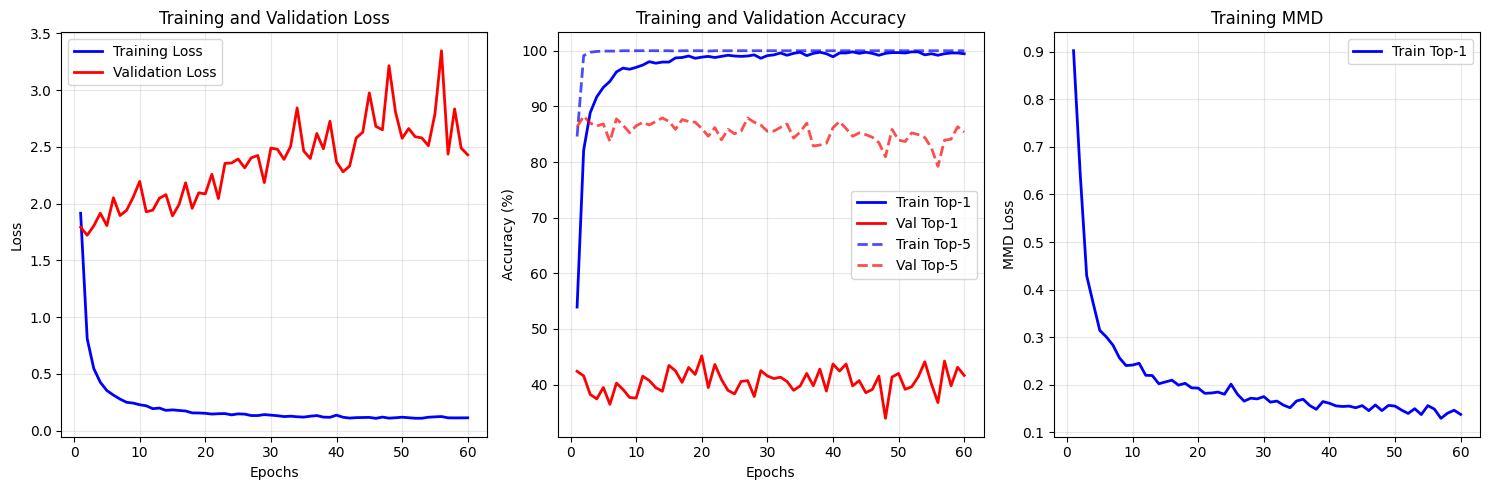

In [16]:
plot_training_metrics(metrics)